<a href="https://colab.research.google.com/github/santosoj160/customer-segmentation-rfm-superstore/blob/main/Customer_Segmentation_RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Load Data

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [18]:
sheet_id = '1K_blmGNV1VkF_ofQJI3x41vV7AW7K_xVf9nh8xrDkVU'
gid = '504608286'

url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'

df = pd.read_csv(url)
print(df.head())

   row_id        order_id  order_date   ship_date       ship_mode customer_id  \
0       1  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156  2016-11-08  2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688  2016-06-12  2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966  2015-10-11  2015-10-18  Standard Class    SO-20335   

     customer_name    segment        country             city  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  postal_code  region       product_id         category subcategory  \
0       42420   South

## Pengecekan kualitas data

In [19]:
#Cek kebersihan data
print("--- SHAPE ---")
print(df.shape, "\n")

print("--- INFO & DATATYPES ---")
df.info()
print("\n--- MISSING VALUES ---")
print(df.isnull().sum(), "\n")

print("--- DUPLICATES ---")
print(f"Total duplikat: {df.duplicated().sum()}\n")

print("--- STATISTIK DESKRIPTIF ---")
display(df.describe())

--- SHAPE ---
(9994, 21) 

--- INFO & DATATYPES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         9994 non-null   int64  
 1   order_id       9994 non-null   object 
 2   order_date     9994 non-null   object 
 3   ship_date      9994 non-null   object 
 4   ship_mode      9994 non-null   object 
 5   customer_id    9994 non-null   object 
 6   customer_name  9994 non-null   object 
 7   segment        9994 non-null   object 
 8   country        9994 non-null   object 
 9   city           9994 non-null   object 
 10  state          9994 non-null   object 
 11  postal_code    9994 non-null   int64  
 12  region         9994 non-null   object 
 13  product_id     9994 non-null   object 
 14  category       9994 non-null   object 
 15  subcategory    9994 non-null   object 
 16  product_name   9994 non-null   object 
 17  

,row_id,postal_code,quantity,discount
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,3.789574,0.156203
std,2885.163629,32063.693350,2.225110,0.206452
min,1.000000,1040.000000,1.000000,0.000000
25%,2499.250000,23223.000000,2.000000,0.000000
50%,4997.500000,56430.500000,3.000000,0.200000
75%,7495.750000,90008.000000,5.000000,0.200000
max,9994.000000,99301.000000,14.000000,0.800000


Karena tipe data gak sesuai maka perlu diubah

In [20]:
# Bersihkan sales dan profit dari titik pemisah ribuan, lalu ubah ke float
df['sales'] = df['sales'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
df['profit'] = df['profit'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

# 2. Ubah format tanggal
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# 3. Ubah postal code jadi string
df['postal_code'] = df['postal_code'].astype(str)

In [21]:
# Cek ulang ringkasan tipe data dan statistik setelah pembersihan
print("--- INFO & DATATYPES SETELAH PERBAIKAN ---")
df.info()

print("\n--- STATISTIK DESKRIPTIF SETELAH PERBAIKAN ---")
display(df.describe())

--- INFO & DATATYPES SETELAH PERBAIKAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   ship_date      9994 non-null   datetime64[ns]
 4   ship_mode      9994 non-null   object        
 5   customer_id    9994 non-null   object        
 6   customer_name  9994 non-null   object        
 7   segment        9994 non-null   object        
 8   country        9994 non-null   object        
 9   city           9994 non-null   object        
 10  state          9994 non-null   object        
 11  postal_code    9994 non-null   object        
 12  region         9994 non-null   object        
 13  product_id     9994 non-null   object        
 14  category       9994 non-null 

,row_id,order_date,ship_date,sales,quantity,discount,profit
count,9994.000000,9994,9994,9.994000e+03,9994.000000,9994.000000,9.994000e+03
mean,4997.500000,2016-04-30 00:07:12.259355392,2016-05-03 23:06:58.571142912,1.132271e+05,3.789574,0.156203,1.801005e+05
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,3.000000e+00,1.000000,0.000000,-3.839990e+07
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,2.516000e+03,2.000000,0.000000,2.245000e+03
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,1.108800e+04,3.000000,0.200000,3.630900e+04
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,5.399175e+04,5.000000,0.200000,1.509840e+05
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,2.396266e+07,14.000000,0.800000,6.719981e+07
std,2885.163629,NaN,NaN,5.186212e+05,2.225110,0.206452,1.722970e+06


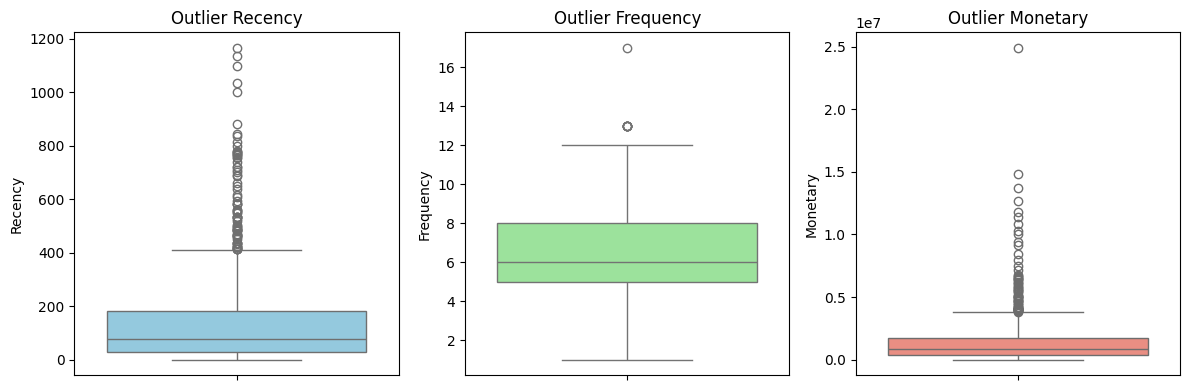

Jumlah outlier pada Recency: 74 baris
Jumlah outlier pada Frequency: 8 baris
Jumlah outlier pada Monetary: 61 baris


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisasi Outlier menggunakan Boxplot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=rfm_df['Recency'], color='skyblue')
plt.title('Outlier Recency')

plt.subplot(1, 3, 2)
sns.boxplot(y=rfm_df['Frequency'], color='lightgreen')
plt.title('Outlier Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(y=rfm_df['Monetary'], color='salmon')
plt.title('Outlier Monetary')

plt.tight_layout()
plt.show()

# 2. Hitung jumlah outlier secara statistik (menggunakan metode IQR)
for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm_df[col].quantile(0.25)
    Q3 = rfm_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = rfm_df[(rfm_df[col] < lower_bound) | (rfm_df[col] > upper_bound)]
    print(f"Jumlah outlier pada {col}: {len(outliers)} baris")

Outlier ini gak  perlu dihapus karena kita menggunakan metode Quartile Scoring (qcut), yang secara otomatis mengelompokkan nilai ekstrem ke dalam skor tertinggi atau terendah tanpa merusak distribusi keseluruhan. jadi biar nilainya gak bias. itu seni di rfm


In [27]:
# 1. Pastikan customer_id bersih dari spasi tersembunyi
df['customer_id'] = df['customer_id'].astype(str).str.strip()

# 2. Filter data anomali / negatif pada Sales jika diperlukan (opsional tapi disarankan agar Monetary valid)
# Mengingat dataset Superstore normalnya tidak bernilai puluhan juta per item tunggal akibat kesalahan parsing titik:
print("Jumlah baris sebelum filter:", len(df))

# Jika ingin membersihkan baris dengan nilai sales atau profit yang ekstrem/tidak wajar akibat salah parsing:
df = df[df['sales'] > 0]

print("Jumlah baris setelah penyesuaian:", len(df))

Jumlah baris sebelum filter: 9994
Jumlah baris setelah penyesuaian: 9994


## agregasi nilai RFM

In [26]:
import datetime as dt

# 1. Tentukan tanggal snapshot (biasanya 1 hari setelah transaksi terakhir di dataset)
snapshot_date = df['order_date'].max() + dt.timedelta(days=1)

# 2. Hitung RFM per customer_id
rfm_df = df.groupby('customer_id').agg({
    'order_date': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                  # Frequency
    'sales': 'sum'                                          # Monetary
})

# 3. Ubah nama kolom agar lebih mudah dibaca
rfm_df.rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'sales': 'Monetary'
}, inplace=True)

# 4. Tampilkan 5 baris teratas hasil perhitungan RFM
print("--- CONTOH DATA RFM ---")
display(rfm_df.head())

--- CONTOH DATA RFM ---


,Recency,Frequency,Monetary
customer_id,,,
AA-10315,185,5,5090484.0
AA-10375,20,9,165678.0
AA-10480,260,4,193048.0
AA-10645,56,6,1737756.0
AB-10015,416,3,143818.0


## Skor (Quartile Scoring 1-5)

In [29]:
# 1. Berikan skor 1-5 menggunakan qcut (1 = terendah, 5 = tertinggi untuk F & M)
# Untuk Recency, skor terbalik: semakin kecil jarak hari (makin baru), skor harus makin tinggi (5)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 2. Gabungkan skor menjadi RFM_Score (string)
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# 3. Buat pengelompokan segmen sederhana berdasarkan skor gabungan
def segment_customer(df):
    if df['RFM_Score'] in ['555', '554', '544', '545', '454', '455', '445']:
        return 'Champions'
    elif df['R_Score'] >= 4 and df['F_Score'] >= 2:
        return 'Loyal Customers'
    elif df['R_Score'] >= 3 and df['F_Score'] == 1:
        return 'Recent Customers'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3:
        return 'At Risk'
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalist'

rfm_df['Segment'] = rfm_df.apply(segment_customer, axis=1)

# 4. Tampilkan hasil distribusi segmen pelanggan
print("--- JUMLAH PELANGGAN PER SEGMEN ---")
print(rfm_df['Segment'].value_counts())

display(rfm_df.head())

--- JUMLAH PELANGGAN PER SEGMEN ---
Segment
Loyal Customers       190
Lost Customers        171
At Risk               145
Potential Loyalist    136
Champions              89
Recent Customers       62
Name: count, dtype: int64


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
customer_id,,,,,,,,
AA-10315,185,5,5090484.0,2,2,5,225,Lost Customers
AA-10375,20,9,165678.0,5,5,1,551,Loyal Customers
AA-10480,260,4,193048.0,1,1,1,111,Lost Customers
AA-10645,56,6,1737756.0,3,3,4,334,Potential Loyalist
AB-10015,416,3,143818.0,1,1,1,111,Lost Customers


In [30]:
# Simpan rfm_df yang sudah memiliki skor dan segment lengkap ke file CSV
target_file = '/content/drive/MyDrive/PROJECT DATA ANALITICS/Customer Segmentation RFM Analysis/Dataset/score_rfm.csv'
rfm_df.to_csv(target_file, index=False)

print("SUKSES! File CSV berhasil tersimpan.")

SUKSES! File CSV berhasil tersimpan.


# Visualisasi

## Matriks RFM & Kontribusi Pendapatan (Treemap / Bar Gabungan)

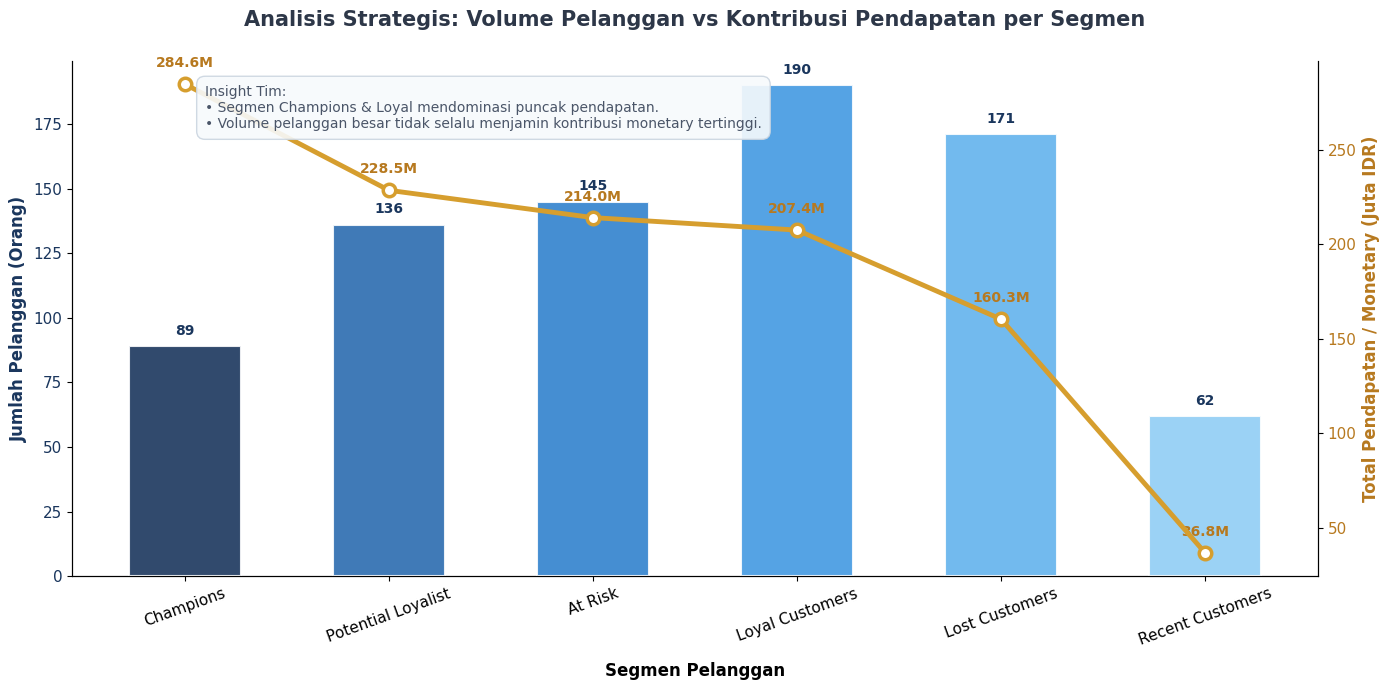

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Siapkan data agregat per segmen dan urutkan
seg_summary = rfm_df.groupby('Segment').agg(
    Customer_Count=('Monetary', 'count'),
    Total_Monetary=('Monetary', 'sum'),
    Avg_Recency=('Recency', 'mean')
).reset_index().sort_values(by='Total_Monetary', ascending=False)

# 2. Inisialisasi plot profesional tanpa garis grid
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.grid(False)

# Warna gradien korporat elegan untuk bar chart
bar_colors = ['#1a365d', '#2b6cb0', '#3182ce', '#4299e1', '#63b3ed', '#90cdf4']

# Plot Bar Chart (Jumlah Pelanggan)
bars = ax1.bar(
    seg_summary['Segment'],
    seg_summary['Customer_Count'],
    color=bar_colors,
    alpha=0.9,
    width=0.55,
    edgecolor='#ffffff',
    linewidth=1.5,
    zorder=3
)

ax1.set_xlabel('Segmen Pelanggan', fontweight='bold', fontsize=12, labelpad=10)
ax1.set_ylabel('Jumlah Pelanggan (Orang)', color='#1a365d', fontweight='bold', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#1a365d', labelsize=11)
ax1.tick_params(axis='x', labelsize=11)
plt.xticks(rotation=20, fontweight='medium')

# Tambahkan angka data label di atas setiap batang
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f'{int(height):,}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#1a365d'
    )

# 3. Sumbu Y kedua untuk Total Revenue / Monetary (Line Chart)
ax2 = ax1.twinx()
ax2.grid(False)

line_values = seg_summary['Total_Monetary'] / 1e6
line = ax2.plot(
    seg_summary['Segment'],
    line_values,
    color='#d69e2e', # Warna Emas untuk Revenue
    marker='o',
    markersize=9,
    markerfacecolor='#ffffff',
    markeredgewidth=2.5,
    linewidth=3.5,
    linestyle='-',
    zorder=4
)

ax2.set_ylabel('Total Pendapatan / Monetary (Juta IDR)', color='#b7791f', fontweight='bold', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#b7791f', labelsize=11)
ax2.spines['top'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Tambahkan nilai data di atas titik garis
for i, txt in enumerate(line_values):
    ax2.annotate(
        f'{txt:.1f}M',
        (seg_summary['Segment'].iloc[i], txt),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#b7791f'
    )

# 4. Judul dan Kotak Keterangan Singkat (Insight Box)
plt.title('Analisis Strategis: Volume Pelanggan vs Kontribusi Pendapatan per Segmen', fontsize=15, fontweight='bold', pad=25, color='#2d3748')

bbox_props = dict(boxstyle="round,pad=0.6", fc="#f7fafc", ec="#cbd5e0", lw=1, alpha=0.9)
plt.figtext(
    0.15, 0.81,
    "Insight Tim:\n• Segmen Champions & Loyal mendominasi puncak pendapatan.\n• Volume pelanggan besar tidak selalu menjamin kontribusi monetary tertinggi.",
    fontsize=10, fontweight='medium', color='#4a5568', bbox=bbox_props
)

plt.tight_layout()
plt.show()

## Peta Sebaran Pelanggan (Scatter Plot ber-Dimensi 4

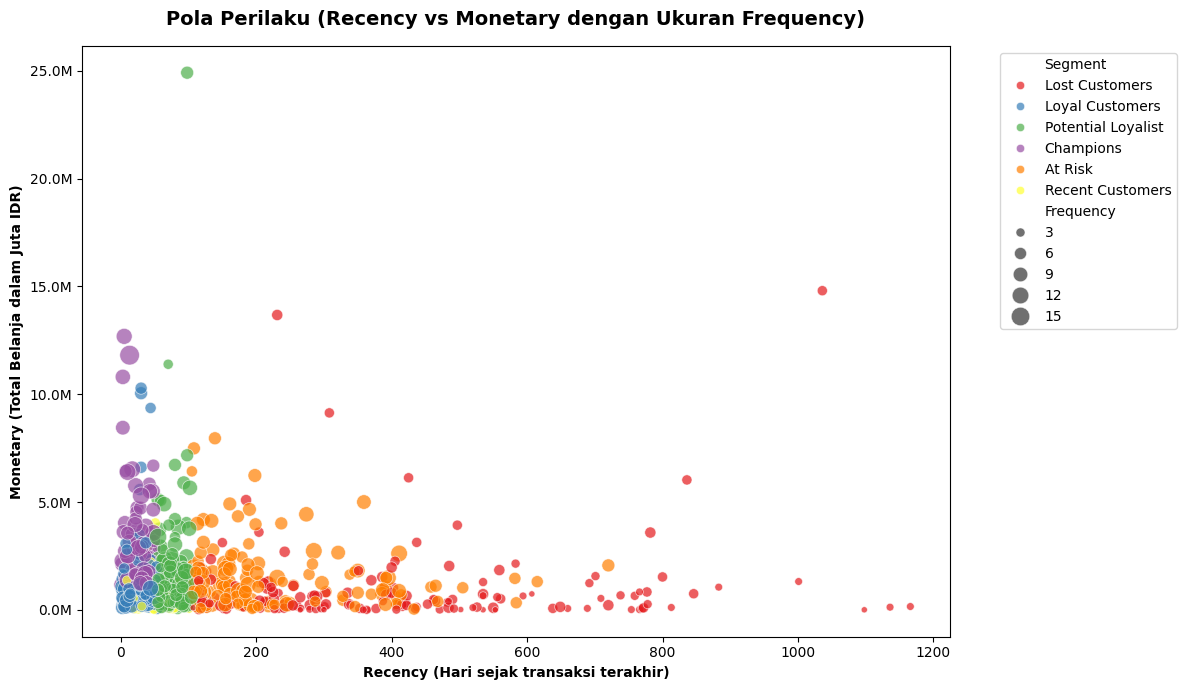

In [33]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=rfm_df,
    x='Recency',
    y='Monetary',
    hue='Segment',
    size='Frequency',
    sizes=(20, 200),
    palette='Set1',
    alpha=0.7
)

# Format sumbu Y agar tampil dalam satuan Juta (M)
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M')
)

plt.title(
    'Pola Perilaku (Recency vs Monetary dengan Ukuran Frequency)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Recency (Hari sejak transaksi terakhir)', fontweight='bold')
plt.ylabel('Monetary (Total Belanja dalam Juta IDR)', fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## Analisis Risiko Kehilangan Pelanggan (Box Plot Distribusi Recency)

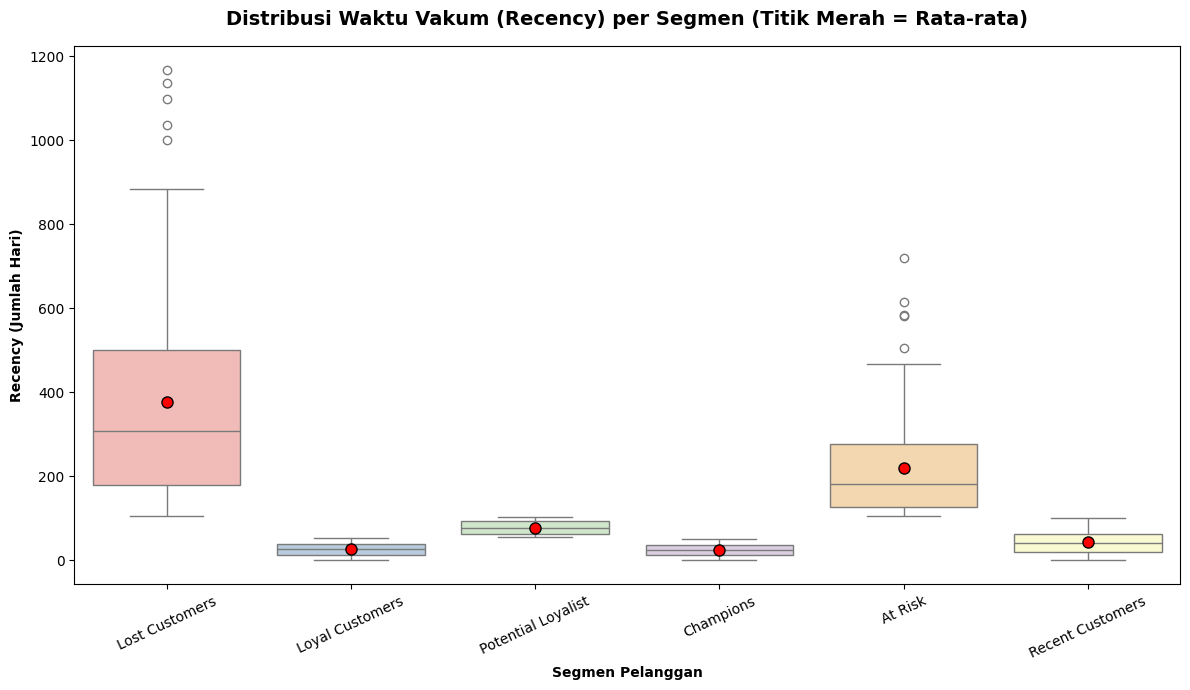

In [34]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=rfm_df,
    x='Segment',
    y='Recency',
    palette='Pastel1',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"}

    )
plt.title('Distribusi Waktu Vakum (Recency) per Segmen (Titik Merah = Rata-rata)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Segmen Pelanggan', fontweight='bold')
plt.ylabel('Recency (Jumlah Hari)', fontweight='bold')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Heatmap Skor RFM Gabungan (Matriks Perilaku)

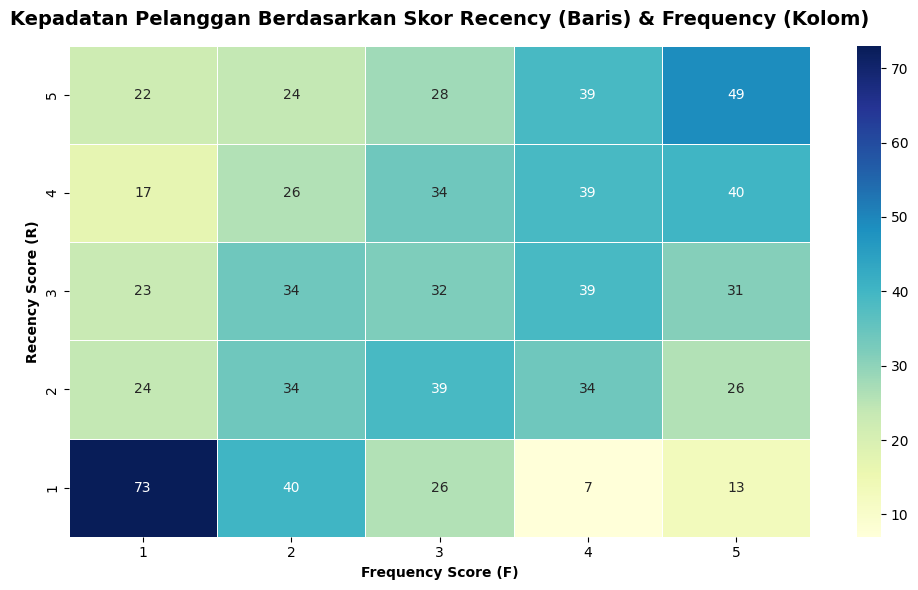

In [35]:
plt.figure(figsize=(10, 6))
# Membuat pivot table sederhana dari skor R dan F
pivot_rfm = rfm_df.pivot_table(index='R_Score', columns='F_Score', values='Monetary', aggfunc='count', fill_value=0)

sns.heatmap(pivot_rfm, annot=True, fmt='d', cmap='YlGnBu', cbar=True, linewidths=.5)
plt.title('Kepadatan Pelanggan Berdasarkan Skor Recency (Baris) & Frequency (Kolom)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency Score (F)', fontweight='bold')
plt.ylabel('Recency Score (R)', fontweight='bold')
plt.tight_layout()
plt.show()

## KPI Summary

In [36]:
# --- 1. RINGKASAN KPI UTAMA ---
total_customers = rfm_df.shape[0]
total_revenue = rfm_df['Monetary'].sum()
avg_revenue = rfm_df['Monetary'].mean()
avg_frequency = rfm_df['Frequency'].mean()
avg_recency = rfm_df['Recency'].mean()

print("==================================================")
print("       EXECUTIVE SUMMARY / FULL KPI RFM           ")
print("==================================================")
print(f"• Total Pelanggan Unik     : {total_customers:,} orang")
print(f"• Total Pendapatan         : Rp {total_revenue:,.2f}")
print(f"• Rata-rata Nilai Belanja  : Rp {avg_revenue:,.2f} per pelanggan")
print(f"• Rata-rata Frekuensi Order: {avg_frequency:.1f} kali transaksi")
print(f"• Rata-rata Recency        : {avg_recency:.1f} hari sejak transaksi terakhir")
print("==================================================")

# --- 3. SIMPAN HASIL KE CSV ---
from google.colab import drive
import os

# 1. Mount Google Drive (jika belum pernah di-mount pada sesi ini)
drive.mount('/content/drive')

# 2. Tentukan jalur folder tujuan di Google Drive
target_dir = '/content/drive/MyDrive/PROJECT DATA ANALITICS/Customer Segmentation RFM Analysis/Dataset'

# 3. Buat foldernya jika belum ada
os.makedirs(target_dir, exist_ok=True)

# 4. Simpan dataframe yang sudah bersih ke dalam folder tersebut
file_path = os.path.join(target_dir, 'clean_customer_segmentation.csv')
df.to_csv(file_path, index=False)

print(f"File berhasil disimpan secara permanen di: {file_path}")

       EXECUTIVE SUMMARY / FULL KPI RFM           
• Total Pelanggan Unik     : 793 orang
• Total Pendapatan         : Rp 1,131,591,720.00
• Rata-rata Nilai Belanja  : Rp 1,426,975.69 per pelanggan
• Rata-rata Frekuensi Order: 6.3 kali transaksi
• Rata-rata Recency        : 147.8 hari sejak transaksi terakhir
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File berhasil disimpan secara permanen di: /content/drive/MyDrive/PROJECT DATA ANALITICS/Customer Segmentation RFM Analysis/Dataset/clean_customer_segmentation.csv
